In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

In [6]:
import torch
from torchvision import datasets, transforms

# Define your transform (without Normalize)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Load dataset to calculate mean and std
dataset = datasets.ImageFolder(root=r'C:\Users\Lenovo\Desktop\programming\TASKS-&-PROJECTS-2024-25\MM&AM\DATA\dataset\Training', transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

# Calculate mean and std
mean = 0.0
std = 0.0
for images, _ in loader:
    batch_samples = images.size(0)  # Batch size
    images = images.view(batch_samples, images.size(1), -1)  # Flatten the image
    mean += images.mean(2).sum(0)  # Sum over batch and width/height
    std += images.std(2).sum(0)

mean /= len(loader.dataset)
std /= len(loader.dataset)

print(f'Mean: {mean}, Std: {std}')

Mean: tensor([0.1731]), Std: tensor([0.1774])


In [8]:
# Définition des transformations pour le prétraitement des images
transform = transforms.Compose([
    transforms.Grayscale(),        # Conversion en niveau de gris
    transforms.Resize((256, 256)), # Redimensionnement des images à 256x256
    transforms.ToTensor(),         # Conversion en tenseur pour PyTorch
    # transforms.Normalize(mean=[0.1731], std=[0.1774]) # commonly used normalization scheme applied to ImageNet-trained models
])

In [10]:
# Création de la classe Dataset personnalisée pour charger les images
class TumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Parcourir les sous-dossiers et enregistrer les chemins des images et leurs étiquettes
        for label, sub_dir in enumerate(['no_tumor', 'glioma_tumor']): # no_tumor_label = 0 and tumor_label = 1
            folder = os.path.join(root_dir, sub_dir)
            for filename in os.listdir(folder):
                self.image_paths.append(os.path.join(folder, filename))
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx])
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [14]:
# Add early stopping function
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                
# Initialize early stopping
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

In [16]:
# Définition de l'opération morphologique personnalisée
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define custom morphological operations
class MorphologicalOperation(nn.Module):
    def __init__(self, operation):
        super(MorphologicalOperation, self).__init__()
        self.operation = operation

    def forward(self, x):
        if x.dim() == 3:  # Ensure 4D tensor
            x = x.unsqueeze(0)
        if self.operation == 'dilation':
            return F.max_pool2d(x, kernel_size=5, stride=1, padding=2)
        elif self.operation == 'erosion':
            return -F.max_pool2d(-x, kernel_size=5, stride=1, padding=2)
        elif self.operation == 'opening':
            eroded = -F.max_pool2d(-x, kernel_size=5, stride=1, padding=2)
            return F.max_pool2d(eroded, kernel_size=5, stride=1, padding=2)
        elif self.operation == 'closing':
            dilated = F.max_pool2d(x, kernel_size=5, stride=1, padding=2)
            return -F.max_pool2d(-dilated, kernel_size=5, stride=1, padding=2)
        elif self.operation == 'residual':
            dilated = F.max_pool2d(x, kernel_size=5, stride=1, padding=2)
            eroded = -F.max_pool2d(-x, kernel_size=5, stride=1, padding=2)
            return x - eroded

# Morphological layer with max pooling
class MorphologicalLayer(nn.Module):
    def __init__(self):
        super(MorphologicalLayer, self).__init__()
        self.dilation = MorphologicalOperation('dilation')
        self.erosion = MorphologicalOperation('erosion')
        self.opening = MorphologicalOperation('opening')
        self.closing = MorphologicalOperation('closing')
        self.residual = MorphologicalOperation('residual')
        self.relu = nn.ReLU()  # Add ReLU activation

    def forward(self, x):
        dilated = self.dilation(x)
        eroded = self.erosion(x)
        opened = self.opening(x)
        closed = self.closing(x)
        residual = self.residual(x)
        return torch.cat([dilated, eroded, opened, closed, residual], dim=1)


# Définition de l'architecture du modèle avec MaxPooling
# Modified HybridCNN with Dropout
class HybridCNN(nn.Module):
    def __init__(self):
        super(HybridCNN, self).__init__()
        self.morph_layer = MorphologicalLayer()
        self.pool_morph = nn.MaxPool2d(2, 2)  # Add pooling after morphology
        self.conv1 = nn.Conv2d(5, 16, kernel_size=5, stride=1, padding=2)
        self.pool = nn.MaxPool2d(2, 2)  # MaxPooling layer
        self.fc1 = nn.Linear(16 * 64 * 64, 512)  # Updated based on pooling output size
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.morph_layer(x)
        x = self.pool_morph(x)  # Apply pooling after morphological layer
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset


# Load datasets
# train_dataset_no_tumor = TumorDataset(r'C:\Users\Lenovo\Desktop\programming\TASKS-&-PROJECTS-2024-25\MM&AM\DATA\dataset\Training\no_tumor', label=0, transform=transform)
# train_dataset_tumor = TumorDataset(r'C:\Users\Lenovo\Desktop\programming\TASKS-&-PROJECTS-2024-25\MM&AM\DATA\dataset\Training\glioma_tumor', label=1, transform=transform)

# Combine datasets and create DataLoader
# train_dataset = torch.utils.data.ConcatDataset([train_dataset_no_tumor, train_dataset_tumor])

# Assuming `train_dataset` contains the entire dataset
train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=42)  # 80% train, 20% validation

# Wrapping dataset and val_data in Subset and creating data loaders
train_loader = DataLoader(Subset(dataset, train_data), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(dataset, val_data), batch_size=32, shuffle=False)  # No shuffle for validation data

# Initialize model, criterion, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridCNN().to(device)

# Class weights
class_weights = torch.tensor([827 / (333 + 827), 333 / (333 + 827)]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 regularization with weight_decay
scheduler = StepLR(optimizer, step_size=5, gamma=0.7)

# Helper function to visualize feature maps
def visualize_feature_maps(feature_maps, title):
    num_maps = feature_maps.shape[1]
    fig, axes = plt.subplots(1, num_maps, figsize=(20, 5))
    for i, ax in enumerate(axes.flat):
        if i < num_maps:
            ax.imshow(feature_maps[0, i].cpu().detach().numpy(), cmap='gray')
            ax.axis('off')
    plt.suptitle(title)
    plt.show()

In [22]:
print(device)

cuda


In [37]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Training loop with visualization
num_epochs = 25
best_val_loss = float('inf')
early_stopping = EarlyStopping(patience=20, min_delta=0.001)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    # Training loop
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Visualize feature maps after first epoch or periodically
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            sample_image, _ = next(iter(val_loader))
            sample_image = sample_image.to(device)

            # Extract morphological feature maps
            morph_maps = model.morph_layer(sample_image)
            visualize_feature_maps(morph_maps, title="Morphological Feature Maps")

            # Extract convolutional feature maps
            conv_maps = F.relu(model.conv1(morph_maps))
            visualize_feature_maps(conv_maps, title="Convolutional Feature Maps")

    # Calculate average loss and metrics for training
    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    
    print(f"Epoch {epoch+1}/{num_epochs} complete")
    print(f"   - Average Loss: {avg_loss:.4f}")
    print(f"   - Accuracy: {accuracy:.4f}")
    print(f"   - Precision: {precision:.4f}")
    print(f"   - Recall: {recall:.4f}")
    print(f"   - F1-Score: {f1:.4f}")

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [39]:
# Validation loop
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = accuracy_score(val_labels, val_preds)
    
    print(f"   - Validation Loss: {avg_val_loss:.4f}")
    print(f"   - Validation Accuracy: {val_accuracy:.4f}")
    
    # Early stopping
    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered!")
        break

    # Update learning rate scheduler
    scheduler.step()
    print(f"   - Learning rate: {scheduler.get_last_lr()}")

IndentationError: unexpected indent (3642553692.py, line 2)

In [27]:
import os
import glob

# Path to your dataset directory
dataset_dir = r'C:\Users\Lenovo\Desktop\programming\TASKS-&-PROJECTS-2024-25\MM&AM\DATA\dataset\Training'

# Subfolders for each class
glioma_tumor_folder = os.path.join(dataset_dir, 'glioma_tumor')
no_tumor_folder = os.path.join(dataset_dir, 'no_tumor')

# Count the number of images in each subfolder
glioma_tumor_images = len(glob.glob(os.path.join(glioma_tumor_folder, '*.jpg')))
no_tumor_images = len(glob.glob(os.path.join(no_tumor_folder, '*.jpg')))

print(f"Number of images in 'glioma_tumor' folder: {glioma_tumor_images}")
print(f"Number of images in 'no_tumor' folder: {no_tumor_images}")


Number of images in 'glioma_tumor' folder: 827
Number of images in 'no_tumor' folder: 331


In [29]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available! GPU is being used.")
    device = torch.device("cuda")
    
    # Get GPU name
    gpu_name = torch.cuda.get_device_name(device)
    print(f"Using GPU: {gpu_name}")
    
    # Check GPU memory allocated and available
    total_memory = torch.cuda.get_device_properties(device).total_memory / 1e9  # in GB
    allocated_memory = torch.cuda.memory_allocated(device) / 1e9  # in GB
    cached_memory = torch.cuda.memory_reserved(device) / 1e9  # in GB

    print(f"Total memory: {total_memory:.2f} GB")
    print(f"Allocated memory: {allocated_memory:.2f} GB")
    print(f"Cached memory: {cached_memory:.2f} GB")
else:
    print("CUDA is not available. Using CPU.")
    device = torch.device("cpu")


CUDA is available! GPU is being used.
Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total memory: 6.44 GB
Allocated memory: 0.00 GB
Cached memory: 0.00 GB


In [224]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Assuming train_loader and val_loader are already set up for training and validation data
num_epochs = 100
best_val_loss = float('inf')
early_stopping = EarlyStopping(patience=20, min_delta=0.001)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Training loop
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    # Calculate average loss and metrics
    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    
    print(f"Epoch {epoch+1}/{num_epochs} complete")
    print(f"   - Average Loss: {avg_loss:.4f}")
    print(f"   - Accuracy: {accuracy:.4f}")
    print(f"   - Precision: {precision:.4f}")
    print(f"   - Recall: {recall:.4f}")
    print(f"   - F1-Score: {f1:.4f}")

    # Validation loop
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = accuracy_score(val_labels, val_preds)
    
    print(f"   - Validation Loss: {avg_val_loss:.4f}")
    print(f"   - Validation Accuracy: {val_accuracy:.4f}")
    
    # Early stopping
    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered!")
        break

    # Update learning rate scheduler
    scheduler.step()
    print(f"   - Learning rate: {scheduler.get_last_lr()}")

# Save the best model
# torch.save(model.state_dict(), 'best_model.pth')

Batch 1/29, Loss: 0.6876
Batch 11/29, Loss: 0.8556
Batch 21/29, Loss: 0.3012
Epoch 1/100 complete
   - Average Loss: 1.3247
   - Accuracy: 0.7791
   - Precision: 0.8962
   - Recall: 0.7813
   - F1-Score: 0.8348
   - Validation Loss: 0.2133
   - Validation Accuracy: 0.9440
   - Learning rate: [0.001]
Batch 1/29, Loss: 0.0522
Batch 11/29, Loss: 0.0781
Batch 21/29, Loss: 0.2033
Epoch 2/100 complete
   - Average Loss: 0.0885
   - Accuracy: 0.9720
   - Precision: 0.9789
   - Recall: 0.9819
   - F1-Score: 0.9804
   - Validation Loss: 0.1914
   - Validation Accuracy: 0.9569
   - Learning rate: [0.001]
Batch 1/29, Loss: 0.0594
Batch 11/29, Loss: 0.0116
Batch 21/29, Loss: 0.0433
Epoch 3/100 complete
   - Average Loss: 0.0429
   - Accuracy: 0.9881
   - Precision: 0.9880
   - Recall: 0.9955
   - F1-Score: 0.9917
   - Validation Loss: 0.1959
   - Validation Accuracy: 0.9612
   - Learning rate: [0.001]
Batch 1/29, Loss: 0.0055
Batch 11/29, Loss: 0.0082
Batch 21/29, Loss: 0.0329
Epoch 4/100 complete

In [226]:
# Visualisation des cartes de caractéristiques avec plusieurs sous-graphiques par ligne
def visualize_morph_layer(image, model):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        # Ensure image has batch dimension, send it to device
        image = image.unsqueeze(0).to(device)  
        
        # Extract feature maps from the morph layer
        morph_output = model.morph_layer(image) 
        morph_output = morph_output.squeeze(0).cpu().numpy()
        
        # Define subplots layout based on the number of features in morph output
        num_features = morph_output.shape[0]
        num_rows = (num_features // 3) + (num_features % 3 > 0)
        fig, axs = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

        # Loop through each feature map in morph layer output
        for i in range(num_features):
            row, col = divmod(i, 3)
            axs[row, col].imshow(morph_output[i], cmap='gray')
            axs[row, col].axis('off')
        
        # Hide any unused subplots if not a multiple of 3
        for j in range(i + 1, num_rows * 3):
            row, col = divmod(j, 3)
            axs[row, col].axis('off')
        
        plt.suptitle("Morph Layer Feature Maps")
        plt.tight_layout()
        plt.show()
        
def visualize_conv1_layer(image, model):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        # Add batch dimension and move to device
        image = image.unsqueeze(0).to(device)
        
        # Pass image through the morphological layer, then first convolutional layer
        morph_output = model.morph_layer(image)
        conv1_output = model.conv1(morph_output)  
        conv1_output = conv1_output.squeeze(0).cpu().numpy()
        
        # Set up subplots
        num_features = conv1_output.shape[0]
        num_rows = (num_features // 3) + (num_features % 3 > 0)
        fig, axs = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

        # Loop through each feature map in conv1 output
        for i in range(num_features):
            row, col = divmod(i, 3)
            axs[row, col].imshow(conv1_output[i], cmap='gray')
            axs[row, col].axis('off')
        
        # Hide any unused subplots if not a multiple of 3
        for j in range(i + 1, num_rows * 3):
            row, col = divmod(j, 3)
            axs[row, col].axis('off')
        
        plt.suptitle("First Convolutional Layer Feature Maps")
        plt.tight_layout()
        plt.show()


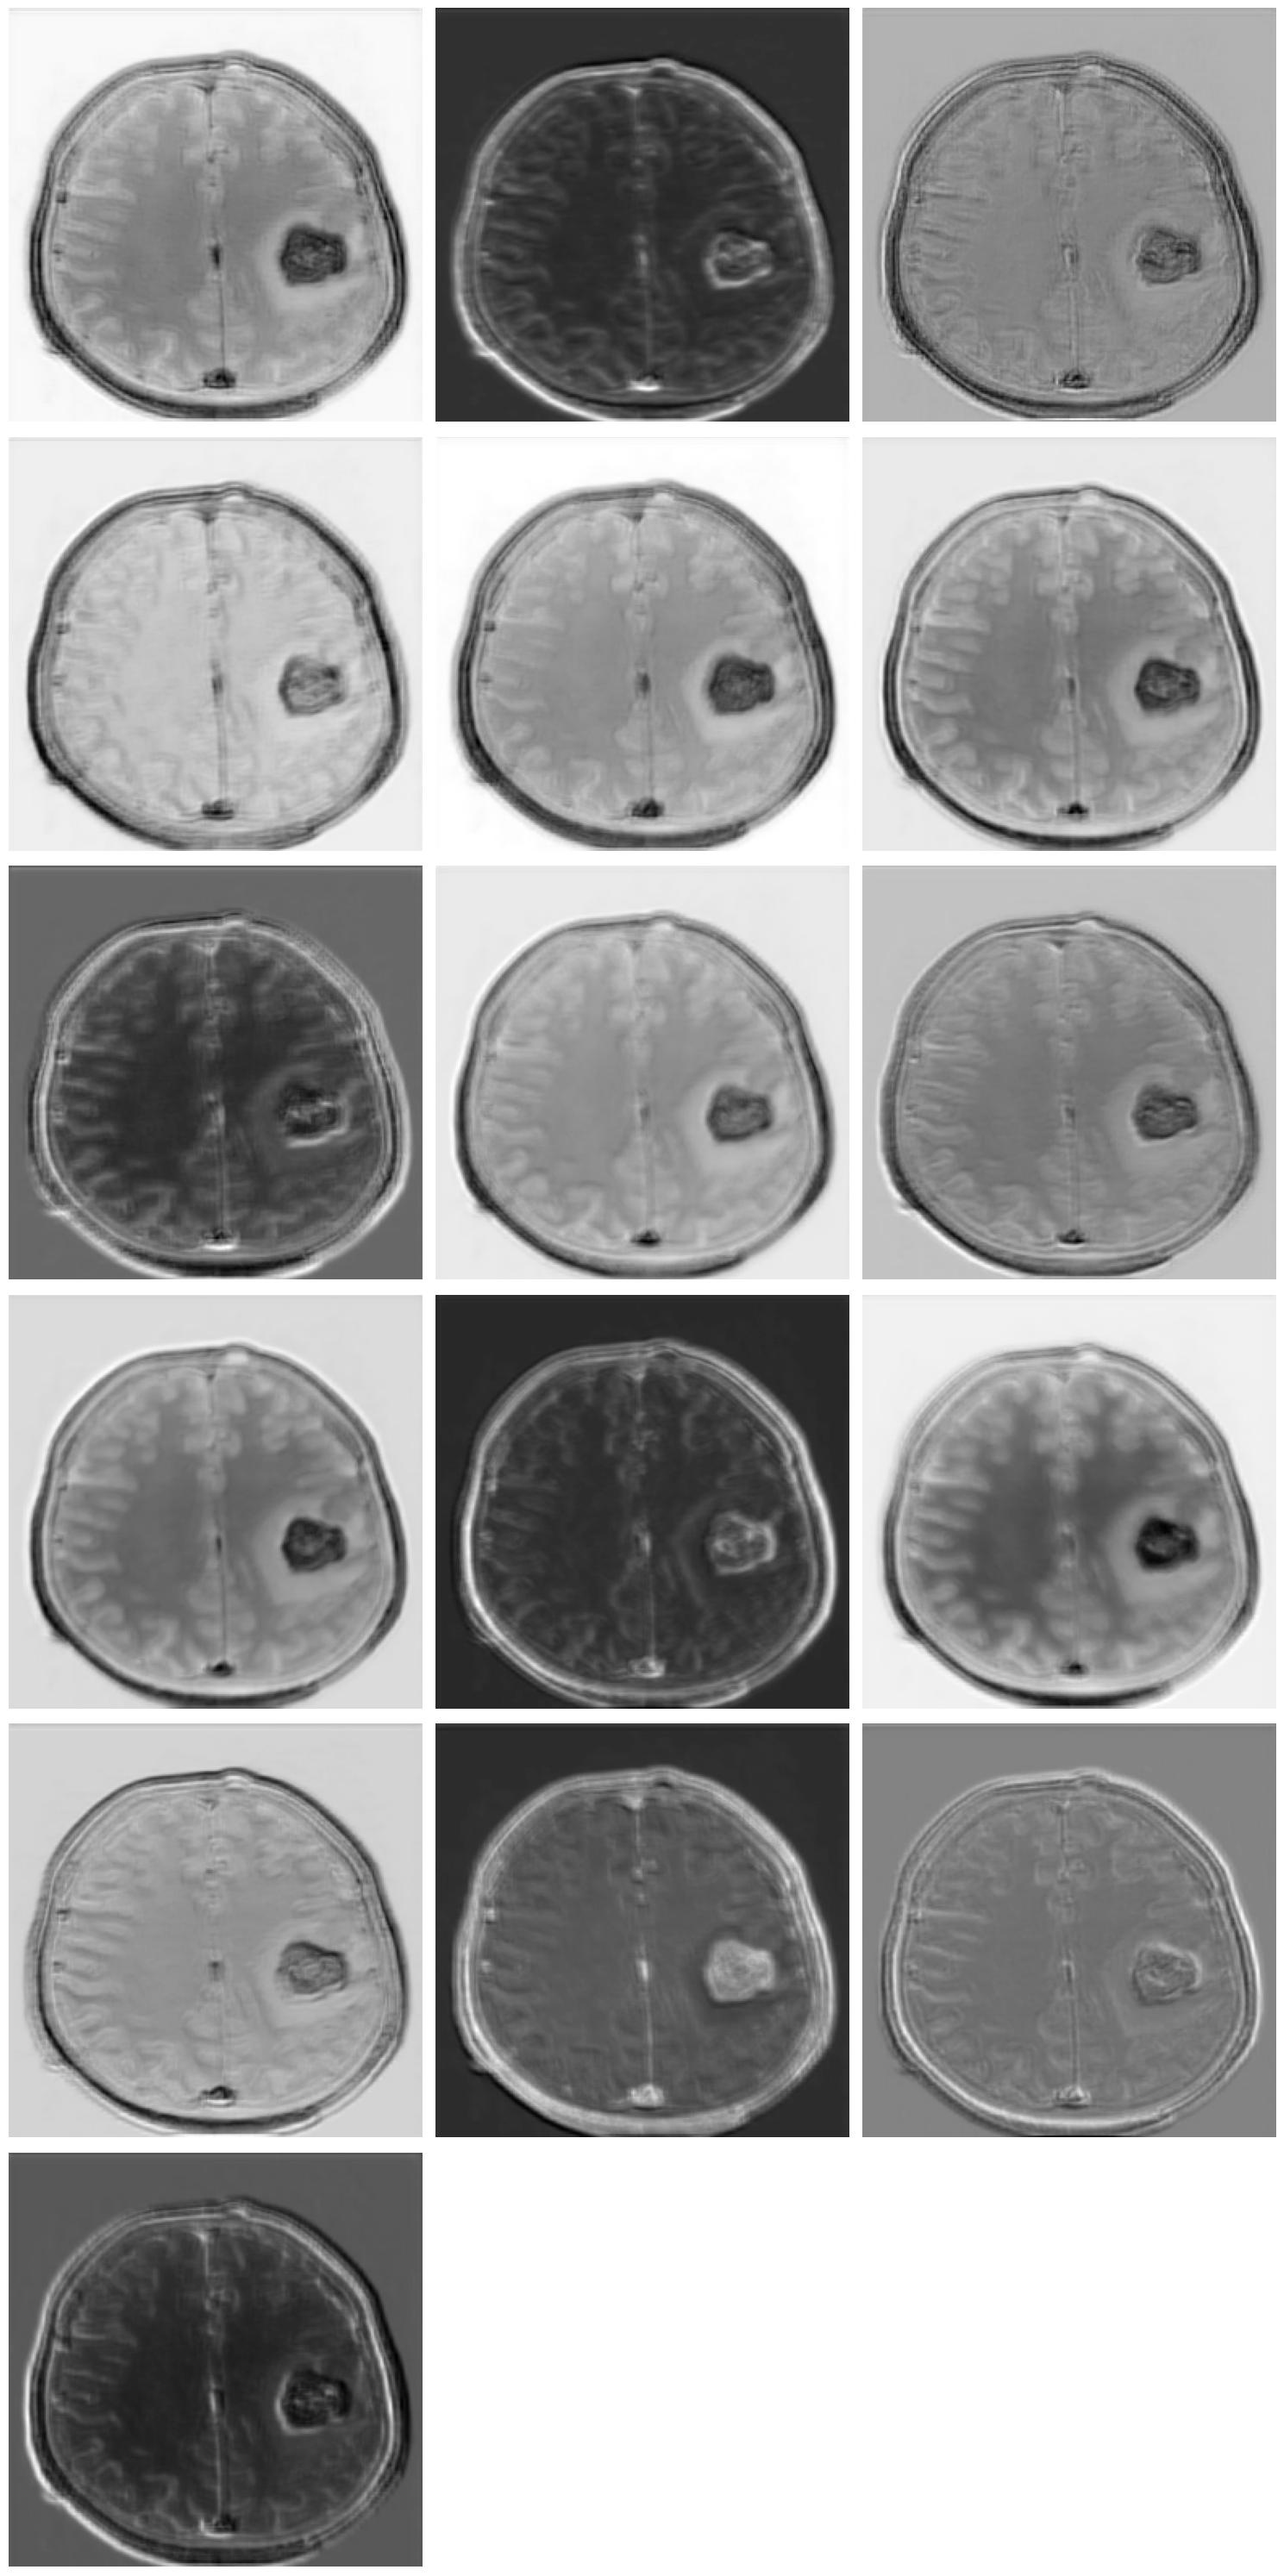

In [230]:
# Tester la visualisation des cartes de caractéristiques sur une image
test_image_path = r'C:\Users\Lenovo\Desktop\programming\TASKS-&-PROJECTS-2024-25\MM&AM\DATA\dataset\Testing\glioma_tumor\image(34).jpg'
test_image = Image.open(test_image_path).convert('L')
test_image = transform(test_image)


visualize_morph_layer(test_image, model)

In [ ]:
visualize_conv1_layer(test_image, model)

Rapport de Classification:
               precision    recall  f1-score   support

    No Tumor     0.5628    0.9810    0.7153       105
       Tumor     0.9091    0.2000    0.3279       100

    accuracy                         0.6000       205
   macro avg     0.7360    0.5905    0.5216       205
weighted avg     0.7317    0.6000    0.5263       205



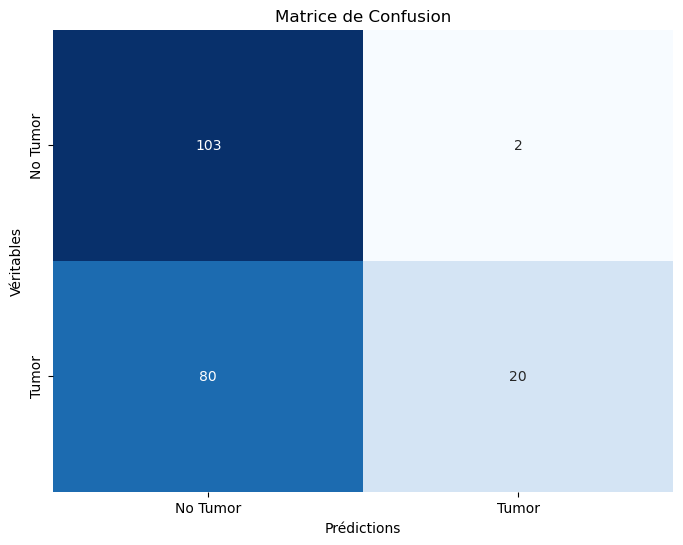

In [208]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Évaluation du modèle avec une meilleure visualisation du rapport de classification et de la matrice de confusion
def evaluate_model(test_loader, model):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Prédire les étiquettes de chaque image du jeu de test
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Afficher le rapport de classification
    report = classification_report(all_labels, all_preds, target_names=['No Tumor', 'Tumor'], digits=4)
    print("Rapport de Classification:\n", report)
    
    # Afficher la matrice de confusion avec Seaborn pour une meilleure clarté
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
    plt.xlabel('Prédictions')
    plt.ylabel('Véritables')
    plt.title('Matrice de Confusion')
    plt.show()

    
    
# Préparation et évaluation sur les données de test
test_dataset = BrainTumorDataset(root_dir=r'C:\Users\Lenovo\Desktop\programming\TASKS-&-PROJECTS-2024-25\MM&AM\DATA\dataset\Testing', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
evaluate_model(test_loader, model)

In [22]:
# Sauvegarde du modèle
torch.save(model.state_dict(), 'hybrid_cnn-74acc.pth')